# Chapter 8 - Implied Volatility and Volatility Models

This notebook introduces implied volatility (IV), illustrates the volatility smile, briefly reviews common volatility models, and shows how machine learning can be used to approximate an implied volatility surface from option data.

## 1. Setup

We start by importing the libraries used throughout the notebook.

In [1]:
# Imports

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Standard library
from math import exp, log, sqrt

# SciPy: statistics, optimization, and interpolation
import scipy.stats as si
from scipy.interpolate import griddata
from scipy.optimize import brentq
from scipy.stats import norm

# Econometric volatility model
from arch import arch_model

# Machine learning: utilities
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning: models
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR

In [2]:
# Notebook setup / execution notes

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)

print("Environment ready")

Environment ready


## 2. Implied Volatility (IV): Definition and Intuition

Implied volatility is the volatility input that makes a pricing model (e.g., Black–Scholes) match the observed market option price.  
In practice, IV is a market-implied parameter that varies across strike and maturity, forming the implied volatility surface.

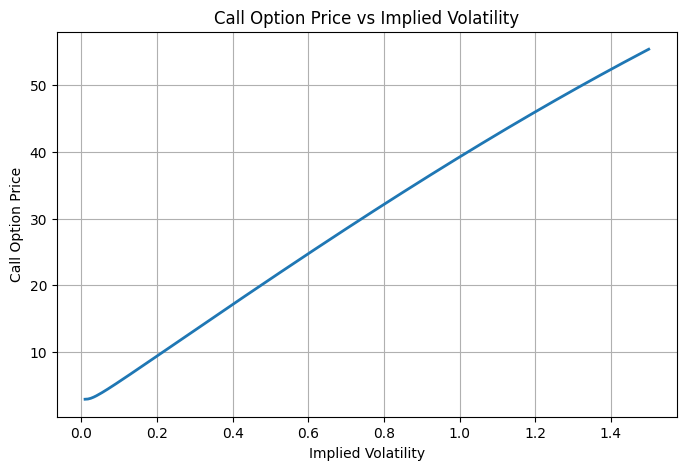

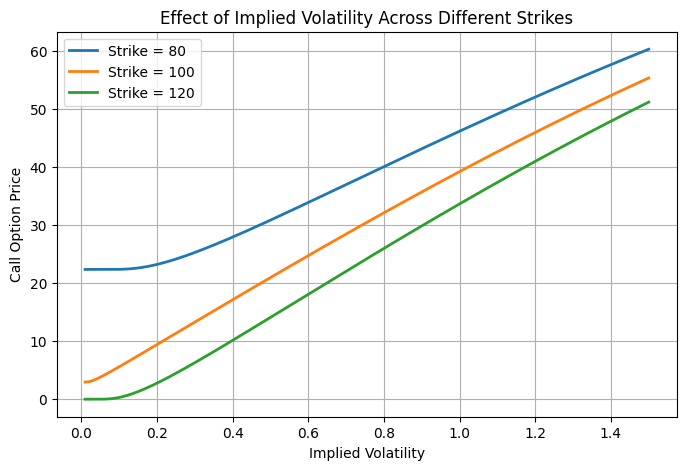

In [3]:
# =========================================================
# Plot 1 and Plot 2: Relationship between implied volatility
# and option prices using Black–Scholes
# =========================================================

# =========================================================
# Step 1: Define Black–Scholes formula
# =========================================================

def mb_bs_formula(S, K, T, r, v, option='call'):
    """
    Compact Black–Scholes closed-form formula using symbolic notation.
    Compute the Black–Scholes price of a European option.
    """
    d1 = (np.log(S / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)

    if option == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    elif option == 'put':
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
    else:
        raise ValueError("Option type must be 'call' or 'put'.")


# -----------------------------
# Common inputs
# -----------------------------
S = 100
T = 1.0              # 1 year to maturity to show curvature more clearly
r = 0.03

vol_range = np.linspace(0.01, 1.50, 200)

# =========================================================
# Plot 1: Call price vs implied volatility (single strike)
# =========================================================
K_plot1 = 100  # ATM strike

call_prices_plot1 = [
    mb_bs_formula(S, K_plot1, T, r, v, option='call')
    for v in vol_range
]

plt.figure(figsize=(8, 5))
plt.plot(vol_range, call_prices_plot1, linewidth=2)
plt.xlabel("Implied Volatility")
plt.ylabel("Call Option Price")
plt.title("Call Option Price vs Implied Volatility")
plt.grid(True)
plt.show()


# =========================================================
# Plot 2: Call price vs implied volatility for different strikes
# =========================================================
strike_list = [80, 100, 120]   # ITM, ATM, OTM with wider spacing

plt.figure(figsize=(8, 5))

for K in strike_list:
    call_prices = [
        mb_bs_formula(S, K, T, r, v, option='call')
        for v in vol_range
    ]
    plt.plot(vol_range, call_prices, linewidth=2, label=f"Strike = {K}")

plt.xlabel("Implied Volatility")
plt.ylabel("Call Option Price")
plt.title("Effect of Implied Volatility Across Different Strikes")
plt.legend()
plt.grid(True)
plt.show()

### 2.1 Volatility Smile and Skew

Market IV is typically not flat across strikes. Instead, it forms a smile or skew that reflects supply/demand, tail risk, and regime effects.  
The goal of this section is to visualize this behavior before modeling it.

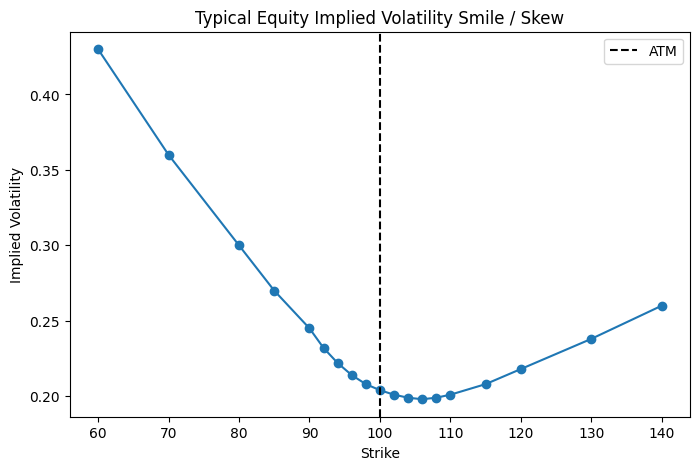

In [4]:
# Volatility smile / skew illustration

# Synthetic market-style volatility smile (smooth skewed parabola)

S0 = 100

strikes = np.array([
    60,70,80,85,90,92,94,96,98,100,
    102,104,106,108,110,115,120,130,140
])

iv = np.array([
    0.430,0.360,0.300,0.270,0.245,0.232,0.222,0.214,0.208,0.204,
    0.201,0.199,0.198,0.199,0.201,0.208,0.218,0.238,0.260
])

plt.figure(figsize=(8,5))
plt.plot(strikes, iv, marker='o')
plt.axvline(S0, linestyle='--', color='black', label='ATM')
plt.title("Typical Equity Implied Volatility Smile / Skew")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()


### 2.1 Important Note on Implied Volatiltity
We do not observe volatility directly.
The market gives option prices.
Implied volatility is the value of 𝜎 that makes a pricing model match the observed market price.
In the next section, we show how this is computed in practice using Black–Scholes and a root-finding method.

## 3. Volatility Models: A Practical Overview

Different volatility models are used for different purposes:

- Historical/conditional volatility models (e.g., GARCH): explain or forecast realized volatility behavior.
- Parametric IV surface models (e.g., SABR): fit implied vol across strikes/maturities for a snapshot.
- Simulation-based approaches: generate distributions and price path-dependent payoffs.

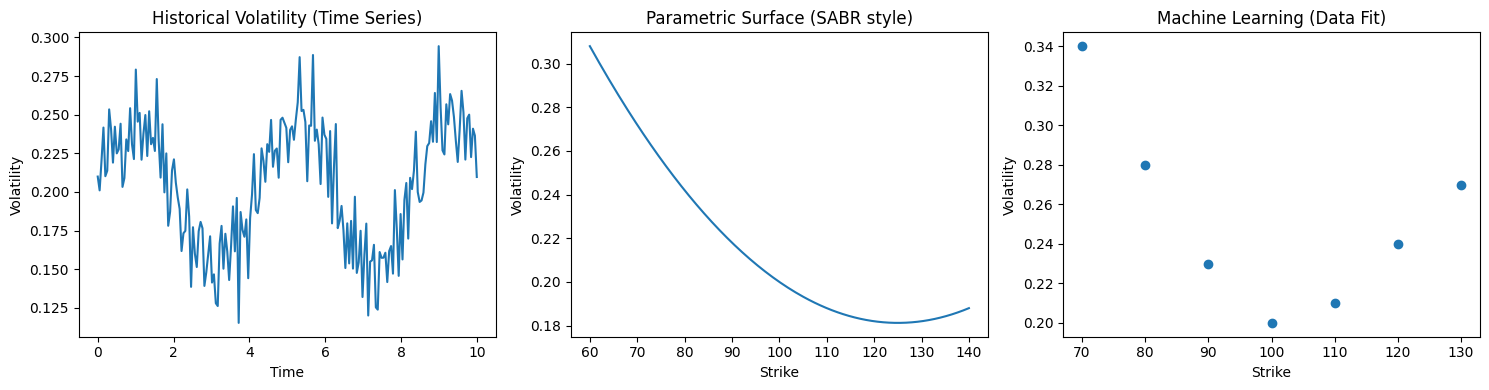

In [5]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

# 1) Historical volatility (time series)
t = np.linspace(0,10,200)
garch_vol = 0.2 + 0.05*np.sin(1.5*t) + 0.02*np.random.randn(len(t))
axes[0].plot(t, garch_vol)
axes[0].set_title("Historical Volatility (Time Series)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Volatility")

# 2) Parametric surface slice (strike dimension)
K = np.linspace(60,140,200)
sabr_vol = 0.20 + 0.30*((K/100 - 1)**2) - 0.15*(K/100 - 1)
axes[1].plot(K, sabr_vol)
axes[1].set_title("Parametric Surface (SABR style)")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Volatility")

# 3) ML data fit
K_pts = np.array([70,80,90,100,110,120,130])
ml_vol = np.array([0.34,0.28,0.23,0.20,0.21,0.24,0.27])
axes[2].scatter(K_pts, ml_vol)
axes[2].set_title("Machine Learning (Data Fit)")
axes[2].set_xlabel("Strike")
axes[2].set_ylabel("Volatility")

plt.tight_layout()
plt.show()


##### Output explanation:
Left: volatility evolves through time → forecasting problem
Middle: volatility varies across strikes → calibration problem
Right: data points → learning problem

Volatility modeling depends on the dimension being studied.
Historical models describe how volatility evolves over time.
Parametric surface models describe how implied volatility varies across strikes and maturities at a given moment.
Machine learning methods learn this cross-sectional relationship directly from observed option data.

## 4. Black–Scholes Recap

Black–Scholes provides a closed-form European option price given inputs:

    - S : float, spot price of the underlying asset
    - K : float, strike price
    - T : float, time to maturity (in years)
    - r : float, risk-free interest rate
    - v : float, volatility of the underlying asset
    - option : str, 'call' or 'put'

Implied volatility is obtained by numerically inverting the pricing formula to solve for "v" given the market option price.

In [6]:
# Black–Scholes pricing example: From Price to Volatility (Implied Volatility demonstration)

# Step 1: define Black–Scholes call price

def mb_bs_formula(S, K, T, r, v, option='call'):
    """
    Compact Black–Scholes closed-form formula using symbolic notation.
    Compute the Black–Scholes price of a European option.
    
    Parameters
    ----------
    S : float, spot price of the underlying asset
    K : float, strike price
    T : float, time to maturity (in years)
    r : float, risk-free interest rate
    v : float, volatility of the underlying asset
    option : str, 'call' or 'put'

    Returns
    -------
    float, Black–Scholes option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)

    if option == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

    elif option == 'put':
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

    else:
        raise ValueError("Option type must be 'call' or 'put'.")

In [7]:
# Step 2: choose a "true" volatility and compute market price using mb_bs_formula

S = 100
K = 100
T = 0.5
r = 0.03
true_vol = 0.20

market_price = mb_bs_formula(S, K, T, r, true_vol, option='call')

print(f"Observed market option price: {market_price:.4f}")

Observed market option price: 6.3710


### 3.1 Implied Volatility as an Inverse Problem

Given a market option price, implied volatility is computed by solving:
\[
Price_{BS}(S, K, T, r, \sigma) - Price_{mkt} = 0
\]
This is typically done using a root-finding method (e.g., Brent’s method).

In [8]:
# Implied volatility inversion (root finding)

def implied_vol_call(price, S, K, T, r):
    
    def objective(v):
        return mb_bs_formula(S, K, T, r, v, option='call') - price
    
    return brentq(objective, 1e-6, 3.0)


# Recover implied volatility
recovered_vol = implied_vol_call(market_price, S, K, T, r)

print(f"Recovered implied volatility: {recovered_vol:.4f}")
print(f"Original volatility: {true_vol:.4f}")

Recovered implied volatility: 0.2000
Original volatility: 0.2000


## 5. GARCH (Conditional Volatility)

This section illustrates conditional volatility modeling (historical volatility).  
It is conceptually different from implied volatility surface fitting: GARCH is typically used on returns time series, not option chains.

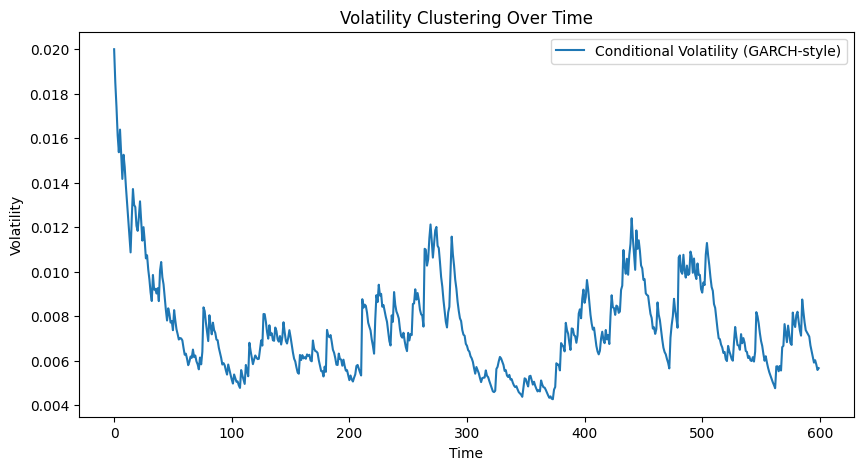

In [9]:
# GARCH-style volatility clustering (no external packages)

np.random.seed(42)

T = 600
omega = 0.000002
alpha = 0.12
beta  = 0.85

returns = np.zeros(T)
sigma2 = np.zeros(T)

sigma2[0] = 0.0004

for t in range(1, T):
    sigma2[t] = omega + alpha*(returns[t-1]**2) + beta*sigma2[t-1]
    returns[t] = np.sqrt(sigma2[t]) * np.random.randn()

vol = np.sqrt(sigma2)

plt.figure(figsize=(10,5))
plt.plot(vol, label="Conditional Volatility (GARCH-style)")
plt.title("Volatility Clustering Over Time")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()


##### GARCH models volatility through time, not across strikes

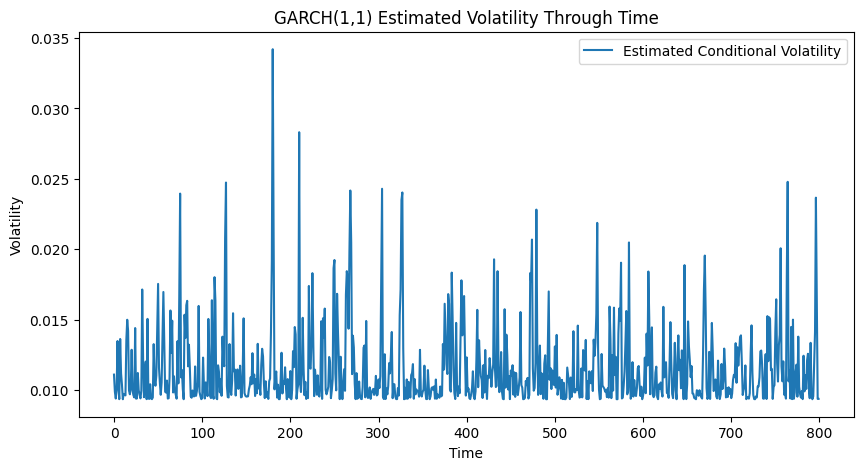

In [10]:
# GARCH(1,1) example — volatility evolving through time

np.random.seed(42)

# --- Simulated returns with clustering ---
T = 800
returns = 0.01 * np.random.randn(T)

for t in range(1, T):
    returns[t] += 0.6 * returns[t-1] * np.random.randn()

# Scale returns for numerical stability
returns_scaled = 100 * returns

# --- Fit GARCH model ---
model = arch_model(returns_scaled, vol='Garch', p=1, q=1)
res = model.fit(disp="off")

# --- Extract conditional volatility ---
# Scale volatility back to original return units
cond_vol = res.conditional_volatility / 100

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(cond_vol, label="Estimated Conditional Volatility")
plt.title("GARCH(1,1) Estimated Volatility Through Time")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()

##### What we observe?

The plot shows that volatility is not constant.
Instead, it appears in bursts:

• quiet periods
• high-volatility regimes
• persistence of shocks

This behavior is known as volatility clustering and is the main motivation behind GARCH models.

This volatility is realized/conditional volatility, not implied volatility.
Option markets then translate expectations about future volatility into the implied volatility surface discussed earlier.

##### Generate forecasts of future volatility

In [11]:
# GARCH(1,1) forecasting example - from conditional volatility to option pricing

# Use clustered returns from the previous section if available;
# otherwise simulate a simple return series
np.random.seed(42)
returns = np.random.normal(0, 1, 1000)

# Fit GARCH(1,1) model
model = arch_model(returns, vol='Garch', p=1, q=1)
model_fit = model.fit(disp="off")

# Print model summary
print(model_fit.summary())

# Forecast future volatility
forecasts = model_fit.forecast(horizon=10)
forecast_volatility = np.sqrt(forecasts.variance.values[-1, :])

print(f"Forecasted volatility for the next 10 periods: {forecast_volatility}")

# Use the average forecasted volatility in Black-Scholes
avg_forecast_volatility = np.mean(forecast_volatility)

S = 145
K = 150
r = 0.02
T = 0.5

call_price = mb_bs_formula(S, K, T, r, avg_forecast_volatility, option='call')

print(f"\nAverage forecasted volatility: {avg_forecast_volatility:.4f}")
print(f"Black-Scholes call price using GARCH forecasted volatility: ${call_price:.2f}")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1397.31
Distribution:                  Normal   AIC:                           2802.61
Method:            Maximum Likelihood   BIC:                           2822.24
                                        No. Observations:                 1000
Date:                Mon, Mar 30 2026   Df Residuals:                      999
Time:                        18:24:07   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0193  3.097e-02      0.624      0.533 

## 6. SABR (Parametric Surface Fitting)

SABR is widely used to fit implied volatility across strikes for a given maturity (and extended to surfaces across maturities).  
This section shows the structure of a SABR-style volatility function and its role as a parametric alternative to direct interpolation.

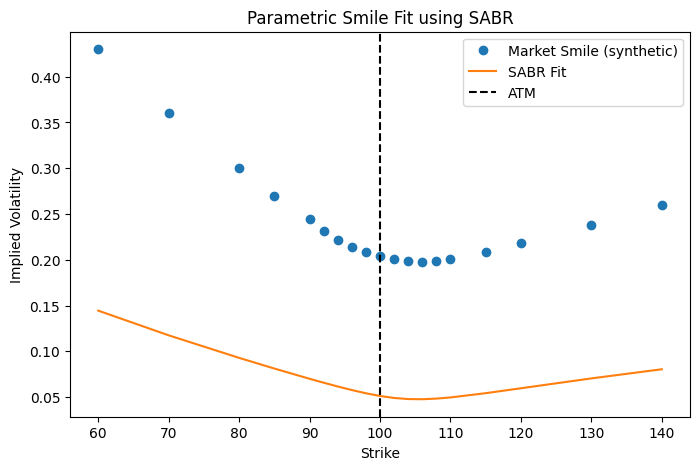

In [12]:
# SABR smile illustration (Hagan 2002 approximation)

def sabr_implied_vol(F, K, T, alpha, beta, rho, nu):
    """
    Hagan SABR implied volatility approximation.
    F: forward price
    K: strike
    T: maturity
    alpha: level
    beta: elasticity (0=normal, 1=lognormal)
    rho: correlation
    nu: vol-of-vol
    """
    
    if F == K:
        # ATM formula
        return (alpha / (F**(1-beta))) * (
            1 + (( (1-beta)**2 * alpha**2 ) / (24 * F**(2-2*beta))
            + (rho*beta*nu*alpha)/(4*F**(1-beta))
            + (nu**2*(2-3*rho**2))/24 ) * T
        )
    
    FK = F*K
    logFK = np.log(F/K)
    
    z = (nu/alpha) * (FK)**((1-beta)/2) * logFK
    xz = np.log((np.sqrt(1 - 2*rho*z + z*z) + z - rho)/(1-rho))
    
    A = alpha / ((FK)**((1-beta)/2) * (1 + ((1-beta)**2/24)*(logFK**2) + ((1-beta)**4/1920)*(logFK**4)))
    
    B = z/xz
    
    C = 1 + (
        ((1-beta)**2 * alpha**2)/(24*(FK)**(1-beta))
        + (rho*beta*nu*alpha)/(4*(FK)**((1-beta)/2))
        + (nu**2*(2-3*rho**2))/24
    ) * T
    
    return A * B * C


# --- Use our synthetic smile strikes ---
F = 100
T = 1.0

# Typical equity skew parameters
alpha = 0.20
beta  = 0.7
rho   = -0.4
nu    = 0.6

sabr_vols = np.array([sabr_implied_vol(F, k, T, alpha, beta, rho, nu) for k in strikes])

# --- Plot comparison ---
plt.figure(figsize=(8,5))
plt.plot(strikes, iv, 'o', label="Market Smile (synthetic)")
plt.plot(strikes, sabr_vols, label="SABR Fit")
plt.axvline(F, linestyle='--', color='black', label='ATM')
plt.title("Parametric Smile Fit using SABR")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()



##### What this result tells us?

The volatility smile is not an arbitrary shape.
A structured stochastic model such as SABR can reproduce its curvature and skew using only a small number of parameters.

However, this comes at a cost:
- parameters must be calibrated
- calibration is numerical and sometimes unstable
- the fit depends on optimization choices and initial guesses
- recalibration is required whenever the market moves

In practice this can become slow and fragile, especially for large option surfaces.
This naturally motivates a different idea: Instead of fitting parameters of a model to the surface, we can directly let a model learn the surface itself.
This is the motivation behind the machine learning approaches introduced in the next section.

## 7. Machine Learning for Implied Volatility Surfaces

In this section, we briefly position machine learning within the option pricing workflow. The goal here is **not** to forecast future volatility. Instead, we use machine learning as a flexible, data-driven tool to approximate the **implied volatility surface observed in the market at a given valuation snapshot**.

To illustrate the idea at a high level, we create a small synthetic example. The first plot shows a simple implied volatility smile for a fixed maturity, while the second extends the same idea to a stylized implied volatility surface across strikes and maturities. The purpose is purely illustrative: to show the type of nonlinear structure that machine learning models can be used to approximate.

In [13]:
np.random.seed(42)

# -----------------------------
# Synthetic 2D smile example
# -----------------------------
spot_price = 100

n = 100
strike_2d = np.linspace(80, 120, n)
time_to_expiration_2d = np.full(n, 90)  # fixed maturity: 90 days

moneyness_2d = strike_2d / spot_price

# Create a clean smile with very small noise
implied_vol_2d = 0.18 + 0.25 * (moneyness_2d - 1.0)**2 + 0.005 * np.random.randn(n)

df_ml = pd.DataFrame({
    "strike": strike_2d,
    "time_to_expiration": time_to_expiration_2d,
    "impliedVolatility": implied_vol_2d
})

# Example features commonly used in ML-based IV surface fitting
df_ml["moneyness"] = df_ml["strike"] / spot_price
df_ml["log_moneyness"] = np.log(df_ml["strike"] / spot_price)
df_ml["ttm_years"] = df_ml["time_to_expiration"] / 365.0

# Example target and feature set
y = df_ml["impliedVolatility"]
X = df_ml[["moneyness", "log_moneyness", "ttm_years"]]

display(X.head())
display(y.head())

# -----------------------------
# Synthetic 3D surface example
# -----------------------------
strike_3d = np.linspace(80, 120, 30)
ttm_3d = np.linspace(30, 365, 30)  # days

K, T = np.meshgrid(strike_3d, ttm_3d)
M = K / spot_price

# Smile + simple term structure
IV_surface = 0.18 + 0.25 * (M - 1.0)**2 + 0.05 * np.sqrt(T / 365.0)

,moneyness,log_moneyness,ttm_years
0,0.800000,-0.223144,0.246575
1,0.804040,-0.218106,0.246575
2,0.808081,-0.213093,0.246575
3,0.812121,-0.208106,0.246575
4,0.816162,-0.203143,0.246575


0    0.192484
1    0.188909
2    0.192447
3    0.196440
4    0.187278
Name: impliedVolatility, dtype: float64

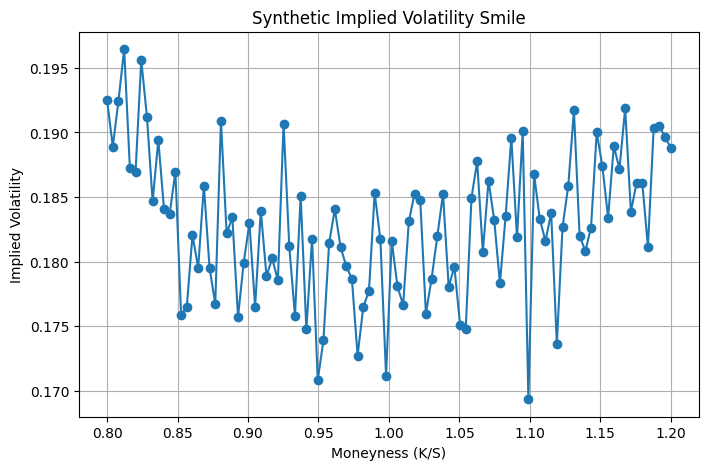

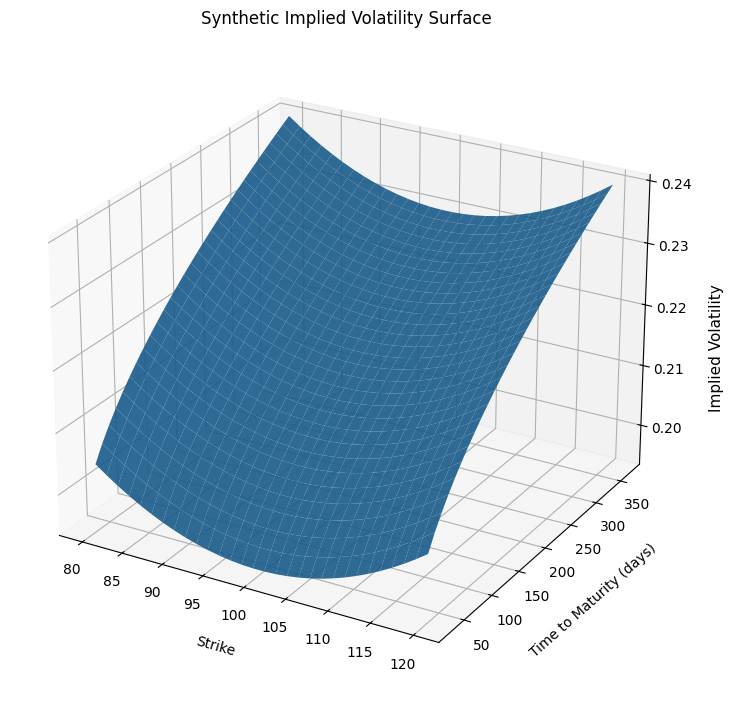

In [14]:
# -----------------------------
# Plot 1: 2D implied volatility smile
# -----------------------------
df_plot = df_ml.sort_values("moneyness")

plt.figure(figsize=(8, 5))
plt.plot(df_plot["moneyness"], df_plot["impliedVolatility"], 'o-')
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Implied Volatility")
plt.title("Synthetic Implied Volatility Smile")
plt.grid(True)
plt.show()

# -----------------------------
# Plot 2: 3D implied volatility surface
# -----------------------------
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(K, T, IV_surface, alpha=0.9)

ax.set_xlabel("Strike", labelpad=10)
ax.set_ylabel("Time to Maturity (days)", labelpad=12)
ax.set_zlabel("")

ax.set_title("Synthetic Implied Volatility Surface", pad=0)
ax.view_init(elev=25, azim=-60)

# Move label closer to the z-axis
fig.text(0.74, 0.52, "Implied Volatility", rotation=90,
         va='center', ha='center', fontsize=11)

plt.subplots_adjust(left=0.05, right=0.90, bottom=0.08, top=0.92)

plt.show()

## 8. Computing Implied Volatility in Python

For completeness, we include a reference implementation showing:
- Black–Scholes pricing
- numerical inversion to solve for implied volatility

In practice, implied volatility is typically obtained by numerically inverting an option pricing model such as Black–Scholes using observed market prices.


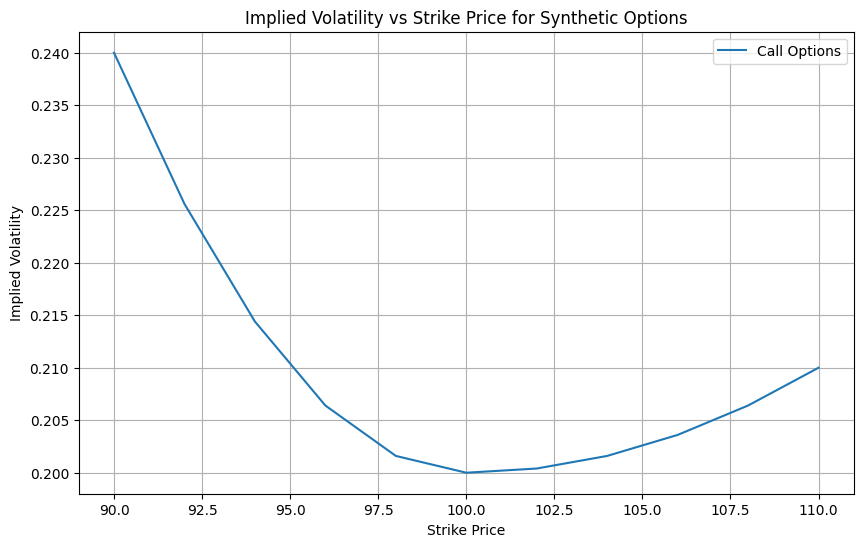

In [15]:
# Define the Black-Scholes price calculation
def mb_black_scholes_price(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        price = (S * norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * norm.cdf(d2, 0.0, 1.0))
    elif option_type == 'put':
        price = (K * np.exp(-r * T) * norm.cdf(-d2, 0.0, 1.0) - S * norm.cdf(-d1, 0.0, 1.0))
    return price

# Constants for Black-Scholes price calculation
spot_price = 100  # current price of the underlying asset
T = 30 / 365  # time to expiry in years
risk_free_rate = 0.01  # risk-free interest rate

# Range of strike prices
strike_prices = np.linspace(90, 110, 11)  # 11 points between 90 and 110

# A skewed implied volatility function that is convex and asymmetric
def mb_skewed_volatility(K):
    if K < spot_price:
        return 0.2 + ((spot_price - K) / 50) ** 2
    else:
        return 0.2 + ((K - spot_price) / 100) ** 2

# Synthetic market prices
market_prices = [mb_black_scholes_price(spot_price, K, T, risk_free_rate, mb_skewed_volatility(K), 'call') for K in strike_prices]

# Dataframe for our synthetic options
options_df = pd.DataFrame({'strike': strike_prices, 'market_price': market_prices})

# Define the implied volatility calculation
def mb_implied_volatility(market_price, S, K, T, r, option_type='call'):
    def mb_price_diff(sigma):
        return mb_black_scholes_price(S, K, T, r, sigma, option_type) - market_price
    iv = brentq(mb_price_diff, 1e-6, 2)
    return iv

# Calculate implied volatility for each strike price
options_df['ImpliedVolatility'] = options_df.apply(lambda row: mb_implied_volatility(row['market_price'], spot_price, row['strike'], T, risk_free_rate, 'call'), axis=1)

# Plot implied volatility
plt.figure(figsize=(10, 6))
plt.plot(options_df['strike'], options_df['ImpliedVolatility'], label='Call Options')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility vs Strike Price for Synthetic Options')
plt.legend()
plt.grid(True)
plt.show()


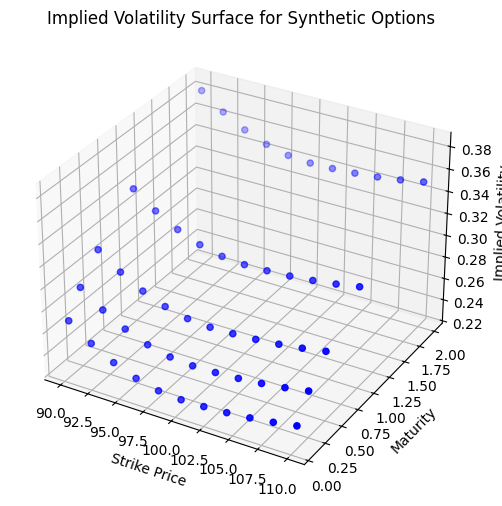

In [16]:
# Constants for Black-Scholes price calculation
spot_price = 100  # current price of the underlying asset
risk_free_rate = 0.01  # risk-free interest rate

# Range of strike prices and maturities
strike_prices = np.linspace(90, 110, 11)  # 11 points between 90 and 110
maturities = np.array([1/12, 3/12, 6/12, 12/12, 24/12])  # in years

# A skewed implied volatility function that is convex and asymmetric and increases with time
def mb_skewed_volatility(K, T):
    base_vol = 0.2 + 0.1 * (T ** 0.5)
    if K < spot_price:
        return base_vol + ((spot_price - K) / 50) ** 2
    else:
        return base_vol + ((K - spot_price) / 100) ** 2

# Synthetic market prices for different maturities
options_df = pd.DataFrame([(K, T, mb_black_scholes_price(spot_price, K, T, risk_free_rate, mb_skewed_volatility(K, T), 'call')) 
                           for K in strike_prices for T in maturities], 
                          columns=['strike', 'maturity', 'market_price'])

# Calculate implied volatility for each strike price and maturity
options_df['ImpliedVolatility'] = options_df.apply(lambda row: mb_implied_volatility(row['market_price'], spot_price, row['strike'], row['maturity'], risk_free_rate, 'call'), axis=1)

# 3D Plot implied volatility
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(options_df['strike'], options_df['maturity'], options_df['ImpliedVolatility'], c='b', marker='o')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Maturity')
ax.set_zlabel('Implied Volatility')
plt.title('Implied Volatility Surface for Synthetic Options')
plt.show()



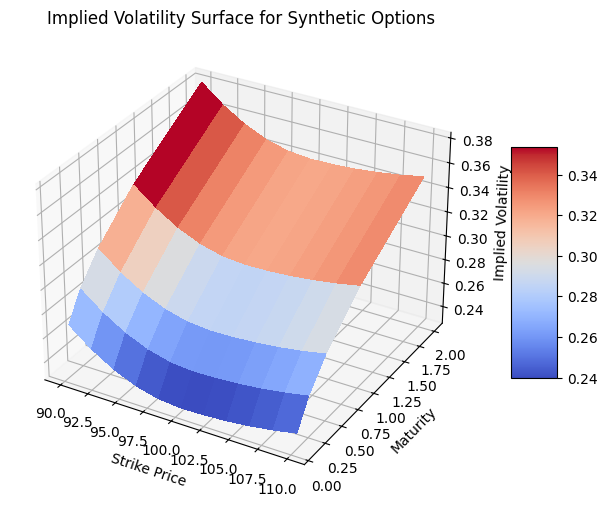

In [17]:
# Constants for Black-Scholes price calculation
spot_price = 100  # current price of the underlying asset
risk_free_rate = 0.01  # risk-free interest rate

# Range of strike prices and maturities
strike_prices = np.linspace(90, 110, 11)  # 11 points between 90 and 110
maturities = np.array([1/12, 3/12, 6/12, 12/12, 24/12])  # in years

# A skewed implied volatility function that is convex and asymmetric and increases with time
def mb_skewed_volatility(K, T):
    base_vol = 0.2 + 0.1 * (T ** 0.5)
    if K < spot_price:
        return base_vol + ((spot_price - K) / 50) ** 2
    else:
        return base_vol + ((K - spot_price) / 100) ** 2

# Synthetic market prices for different maturities
options_df = pd.DataFrame([(K, T, mb_black_scholes_price(spot_price, K, T, risk_free_rate, mb_skewed_volatility(K, T), 'call')) 
                           for K in strike_prices for T in maturities], 
                          columns=['strike', 'maturity', 'market_price'])

# Calculate implied volatility for each strike price and maturity
options_df['ImpliedVolatility'] = options_df.apply(lambda row: mb_implied_volatility(row['market_price'], spot_price, row['strike'], row['maturity'], risk_free_rate, 'call'), axis=1)

# Create a grid of strike prices and maturities
K, T = np.meshgrid(strike_prices, maturities)

# Interpolate implied volatility onto grid
IV = griddata((options_df['strike'], options_df['maturity']), options_df['ImpliedVolatility'], (K, T), method='cubic')

# 3D Plot implied volatility
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K, T, IV, cmap=plt.cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('Strike Price')
ax.set_ylabel('Maturity')
ax.set_zlabel('Implied Volatility')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title('Implied Volatility Surface for Synthetic Options')
plt.show()



In [18]:
# Computing Implied Volatility in Python Example Using Black-Scholes Model

def mb_bs_call_price(S, K, T, r, sigma):
    """
    Black-Scholes price for a European call option.
    """
    if T <= 0:
        return max(S - K, 0.0)
    if sigma <= 0:
        return max(S - K * exp(-r * T), 0.0)

    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    return S * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)


def mb_bs_put_price(S, K, T, r, sigma):
    """
    Black-Scholes price for a European put option.
    """
    if T <= 0:
        return max(K - S, 0.0)
    if sigma <= 0:
        return max(K * exp(-r * T) - S, 0.0)

    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    return K * exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def mb_implied_volatility(price, S, K, T, r, option_type="call"):
    """
    Solve for implied volatility by numerically inverting Black-Scholes.
    """
    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    if option_type.lower() == "call":
        objective = lambda sigma: mb_bs_call_price(S, K, T, r, sigma) - price
    else:
        objective = lambda sigma: mb_bs_put_price(S, K, T, r, sigma) - price

    try:
        iv = brentq(objective, 1e-6, 5.0)
        return iv
    except ValueError:
        return np.nan


# Example: compute IV from a sample market price
S_ex = 273.08
K_ex = 275.00
T_ex = 30 / 365
r_ex = 0.0348
market_price_ex = 8.50

iv_ex = mb_implied_volatility(
    price=market_price_ex,
    S=S_ex,
    K=K_ex,
    T=T_ex,
    r=r_ex,
    option_type="call"
)

print("Example Black-Scholes call price from solved IV:")
print("Implied volatility =", iv_ex)

if not np.isnan(iv_ex):
    check_price = mb_bs_call_price(S_ex, K_ex, T_ex, r_ex, iv_ex)
    print("Repriced call =", check_price)

print("Input price:", market_price_ex)
if not np.isnan(iv_ex):
    print("Repriced difference:", abs(check_price - market_price_ex))


Example Black-Scholes call price from solved IV:
Implied volatility = 0.28943068737054933
Repriced call = 8.5
Input price: 8.5
Repriced difference: 0.0
